# 04 — Comparação dos Modelos

Compara previsões walk-forward usando somente as datas comuns e os mesmos valores reais. O arquivo PLS registra a data de origem; sua previsão de um passo é alinhada ao alvo de `t+1`. Métricas de arquivos auxiliares são informativas; o ranking abaixo é recalculado no período comum.

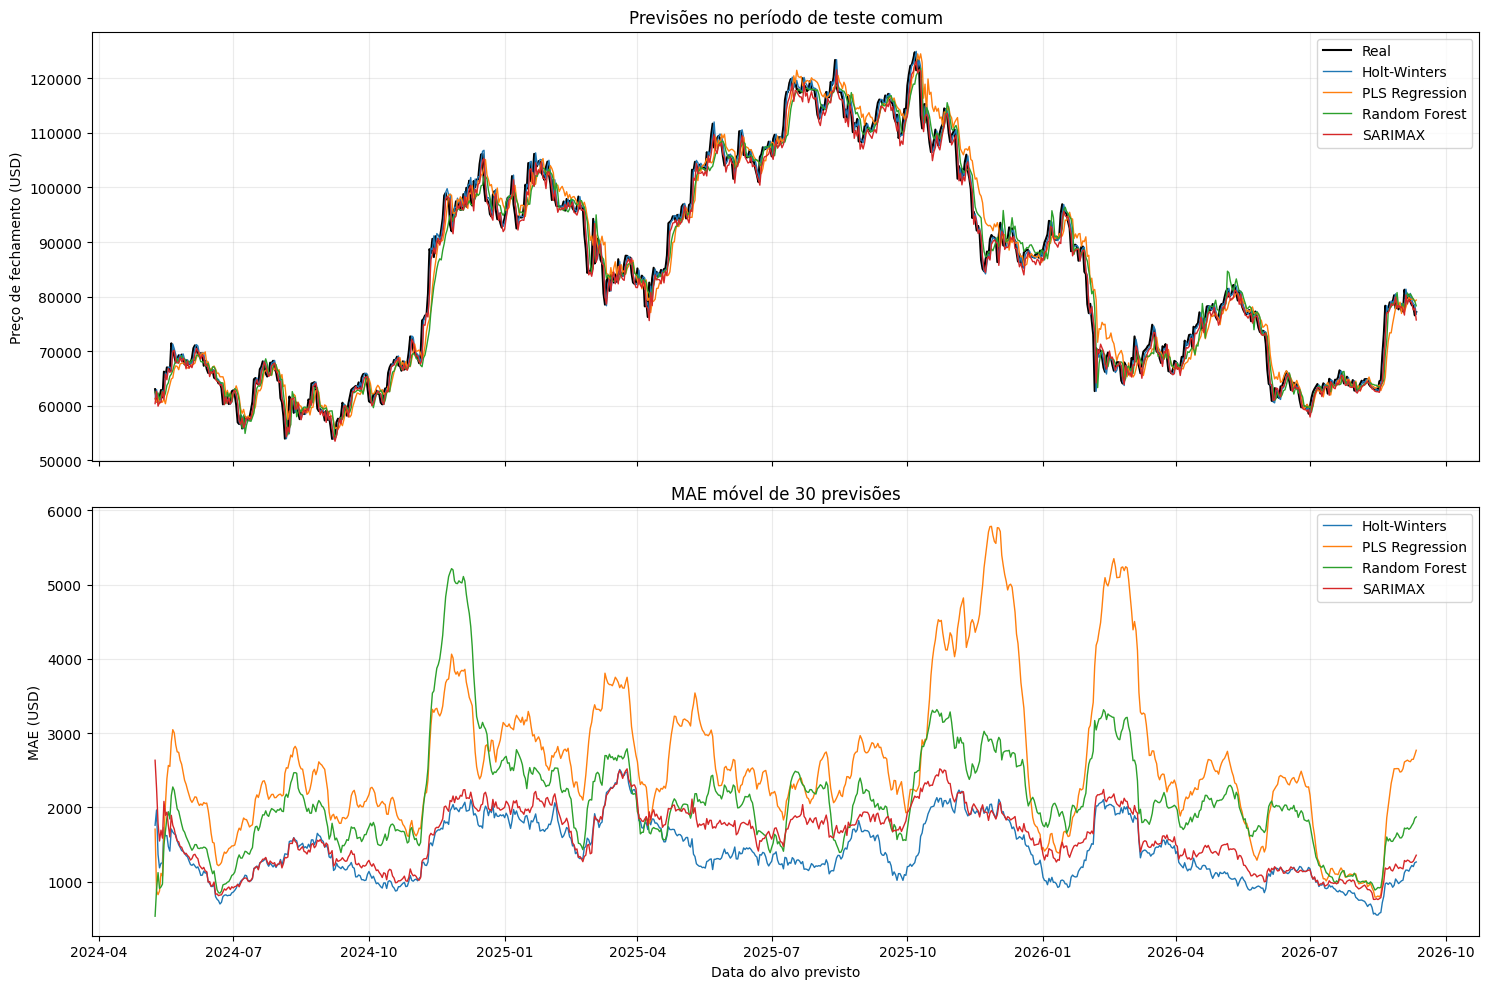

Periodo comum: 2024-05-09 a 2026-09-11 (856 observacoes).
Ranking por MAE recalculado no periodo comum:
        modelo     status  n_periodo_comum     MAE_USD    RMSE_USD  MAPE_pct       R2    bias_USD  tempo_total_s  posicao_MAE
  Holt-Winters Disponivel              856 1406.540849 1963.749080  1.703212 0.989227    2.278829     123.254815            1
PLS Regression Disponivel              856 2608.614507 3521.843601  3.157609 0.965351 -336.247160      24.518066            4
 Random Forest Disponivel              856 2108.001665 2901.947396  2.543061 0.976475  240.770865    3715.095542            3
       SARIMAX Disponivel              856 1590.770367 2130.911742  1.899689 0.987315  693.861757      38.409581            2


In [2]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cwd = Path.cwd().resolve()
project_root = next(
    (path for path in (cwd, *cwd.parents)
     if (path / 'analyses').is_dir() and (path / 'bases').is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')

results_dir = project_root / 'analyses' / 'grupo1' / '03_resultados'
model_root = project_root / 'analyses' / 'grupo1' / '02_modelos'
results_dir.mkdir(parents=True, exist_ok=True)

models = {
    'Holt-Winters': {
        'directory': model_root / 'Holt_Winters',
        'forecast': 'hw_previsoes_walkforward.csv',
        'metrics': 'hw_metricas_walkforward.json',
        'config': 'hw_config_final.json',
        'prediction': 'priceClose_pred_HW',
    },
    'PLS Regression': {
        'directory': model_root / 'PLS_Regression',
        'forecast': 'pls_previsoes_walkforward.csv',
        'metrics': 'pls_metricas_walkforward.json',
        'config': 'pls_config_final.json',
        'prediction': 'priceClose_pred_PLS',
    },
    'Random Forest': {
        'directory': model_root / 'Random_Forest',
        'forecast': 'rf_previsoes_walkforward.csv',
        'metrics': 'rf_metricas_walkforward.json',
        'config': 'rf_config_final.json',
        'prediction': 'priceClose_pred_RF',
    },
    'SARIMAX': {
        'directory': model_root / 'SARIMAX',
        'forecast': 'sarimax_previsoes_walkforward.csv',
        'metrics': 'sarimax_metricas_walkforward.json',
        'config': 'sarimax_config_final.json',
        'prediction': 'priceClose_pred_SARIMAX',
    },
}
forecasts = {}
summary_rows = []
for model_name, spec in models.items():
    forecast_path = spec['directory'] / spec['forecast']
    metrics_path = spec['directory'] / spec['metrics']
    config_path = spec['directory'] / spec['config']
    if not forecast_path.is_file():
        summary_rows.append({
            'modelo': model_name,
            'status': f'Pendente: arquivo ausente ({spec["forecast"]})',
            'n_periodo_comum': 0,
            'MAE_USD': np.nan,
            'RMSE_USD': np.nan,
            'MAPE_pct': np.nan,
            'R2': np.nan,
            'bias_USD': np.nan,
            'tempo_total_s': np.nan,
            'configuracao': None,
        })
        continue

    frame = pd.read_csv(forecast_path, parse_dates=['date']).sort_values('date')
    if model_name == 'PLS Regression':
        frame['date'] = frame['date'] + pd.Timedelta(days=1)
    required = {'date', 'priceClose_real', spec['prediction']}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f'{forecast_path} nao contem as colunas: {sorted(missing)}')
    frame = frame[['date', 'priceClose_real', spec['prediction']]].dropna()
    frame = frame.rename(columns={spec['prediction']: 'previsao'})
    forecasts[model_name] = frame
    metrics = json.loads(metrics_path.read_text(encoding='utf-8')) if metrics_path.is_file() else {}
    config = json.loads(config_path.read_text(encoding='utf-8')) if config_path.is_file() else metrics.get('config_usada')
    summary_rows.append({
        'modelo': model_name,
        'status': 'Disponivel',
        'n_periodo_comum': 0,
        'MAE_USD': np.nan,
        'RMSE_USD': np.nan,
        'MAPE_pct': np.nan,
        'R2': np.nan,
        'bias_USD': np.nan,
        'tempo_total_s': metrics.get('tempo_total_s', np.nan),
        'configuracao': json.dumps(config, ensure_ascii=False) if config is not None else None,
    })

if not forecasts:
    raise FileNotFoundError('Nenhum arquivo de previsoes walk-forward foi encontrado.')
common_dates = sorted(set.intersection(*(set(frame['date']) for frame in forecasts.values())))
if not common_dates:
    raise ValueError('Os modelos disponiveis nao compartilham datas de previsao.')
common_frames = {}
common_truth = None
for model_name, frame in forecasts.items():
    aligned = frame[frame['date'].isin(common_dates)].set_index('date').sort_index()
    truth = aligned['priceClose_real'].astype(float)
    if common_truth is None:
        common_truth = truth
    elif not np.allclose(common_truth.to_numpy(), truth.to_numpy()):
        raise ValueError(f'Valores reais divergentes no periodo comum para {model_name}.')
    aligned['previsao'] = aligned['previsao'].astype(float)
    aligned['residuo'] = truth - aligned['previsao']
    common_frames[model_name] = aligned
    row = next(item for item in summary_rows if item['modelo'] == model_name)
    row.update({
        'n_periodo_comum': len(aligned),
        'MAE_USD': mean_absolute_error(truth, aligned['previsao']),
        'RMSE_USD': mean_squared_error(truth, aligned['previsao']) ** 0.5,
        'MAPE_pct': np.abs((truth - aligned['previsao']) / truth).mean() * 100,
        'R2': r2_score(truth, aligned['previsao']),
        'bias_USD': aligned['residuo'].mean(),
    })

comparacao = pd.DataFrame(summary_rows)
comparacao['posicao_MAE'] = comparacao['MAE_USD'].rank(method='min').astype('Int64')
available = comparacao[comparacao['status'].eq('Disponivel')].sort_values('MAE_USD')
comparacao.to_csv(results_dir / 'comparacao_modelos.csv', index=False)

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
axes[0].plot(common_truth.index, common_truth, color='black', linewidth=1.5, label='Real')
for model_name, frame in common_frames.items():
    axes[0].plot(frame.index, frame['previsao'], linewidth=1, label=model_name)
axes[0].set_title('Previsões no período de teste comum')
axes[0].set_ylabel('Preço de fechamento (USD)')
axes[0].grid(alpha=0.25)
axes[0].legend()
for model_name, frame in common_frames.items():
    rolling_mae = frame['residuo'].abs().rolling(30, min_periods=1).mean()
    axes[1].plot(frame.index, rolling_mae, linewidth=1, label=model_name)
axes[1].set_title('MAE móvel de 30 previsões')
axes[1].set_ylabel('MAE (USD)')
axes[1].set_xlabel('Data do alvo previsto')
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
fig.savefig(results_dir / '04_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Periodo comum: {common_dates[0].date()} a {common_dates[-1].date()} ({len(common_dates)} observacoes).')
print('Ranking por MAE recalculado no periodo comum:')
print(comparacao[['modelo', 'status', 'n_periodo_comum', 'MAE_USD', 'RMSE_USD', 'MAPE_pct', 'R2', 'bias_USD', 'tempo_total_s', 'posicao_MAE']].to_string(index=False))

## Critério de leitura

O ranking usa MAE no intervalo comum, não compara diretamente métricas calculadas em períodos diferentes. HW e PLS são os únicos modelos com previsões presentes nesta execução; RF e SARIMAX serão incorporados automaticamente quando seus arquivos walk-forward existirem. O erro médio (`real - previsto`) negativo indica superestimação das previsões.